# Etapa 5 - Regressão com MLP (alvo: BMI)

Prever o BMI a partir dos demais indicadores de saúde (BMI é removido das features;
as 20 features restantes + `Diabetes_binary` = 21 preditores).

Arquitetura baseline: `Input → Dense(64, relu) → Dropout(0.2) → Dense(32, relu) → Dense(1, linear)`,
loss `mse`, métrica `mae`, Adam(1e-3), `EarlyStopping`, `batch_size=256`.

> Expectativa realista: R² do BMI a partir desses indicadores tende a ser modesto
> (≈0,10–0,30) — os indicadores explicam só parte da variância. Lógica em `src/regression_eval.py`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import pandas as pd
from IPython.display import Image

import config
from src import regression_eval as reg

config.set_seeds()

C:\Users\Tobias Viero\AppData\Local\Temp\ipykernel_17792\3574406107.py:9: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## 1. Treinar e avaliar

Treina a MLP, salva o modelo (`outputs/models/mlp_regression.keras`), avalia uma vez no teste,
gera as figuras e compara com modelos clássicos.

> Resultados já salvos. Para **recomputar** (≈40 s em CPU), execute a célula abaixo.

In [2]:
# Recomputa e salva regression_metrics.json:
# reg.run()

metrics = json.load(open(config.METRICS_DIR / "regression_metrics.json", encoding="utf-8"))
print("alvo:", metrics["target"], "| features:", metrics["n_features"], "| épocas:", metrics["epochs"])
metrics["test"]

alvo: BMI | features: 21 | épocas: 76


{'mae': 4.185824279715984,
 'mse': 36.29391082993857,
 'rmse': 6.0244427816967905,
 'r2': 0.17359423554123177}

## 2. Curva de aprendizado

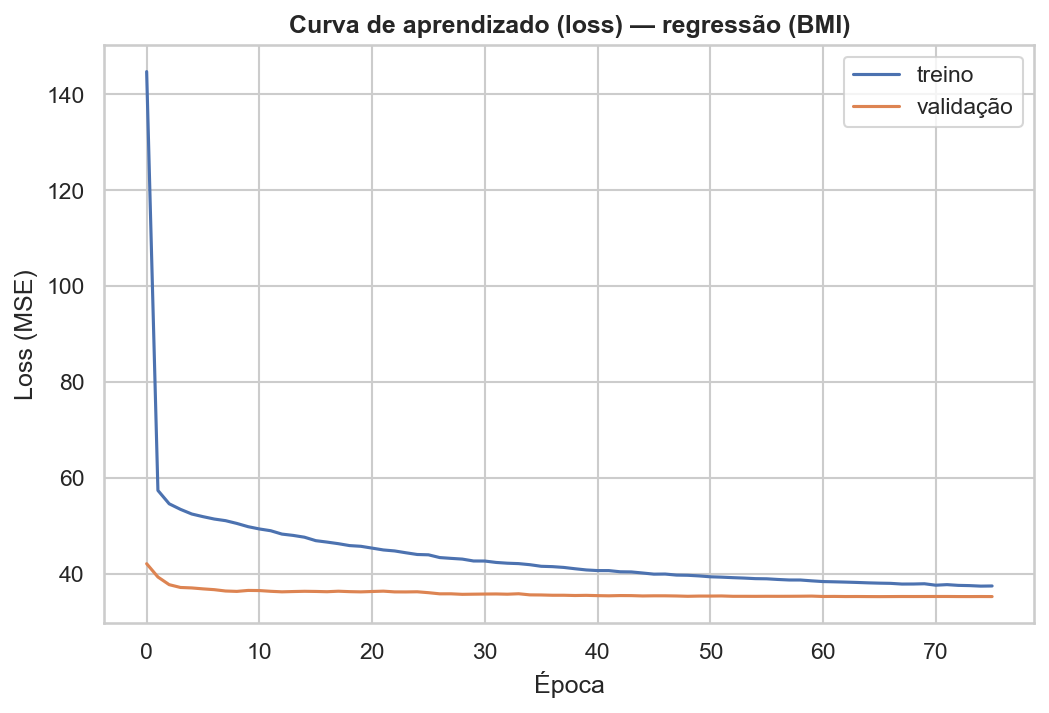

In [3]:
Image(str(config.FIGURES_DIR / "etapa5_loss.png"))

## 3. Real × predito e análise de resíduos

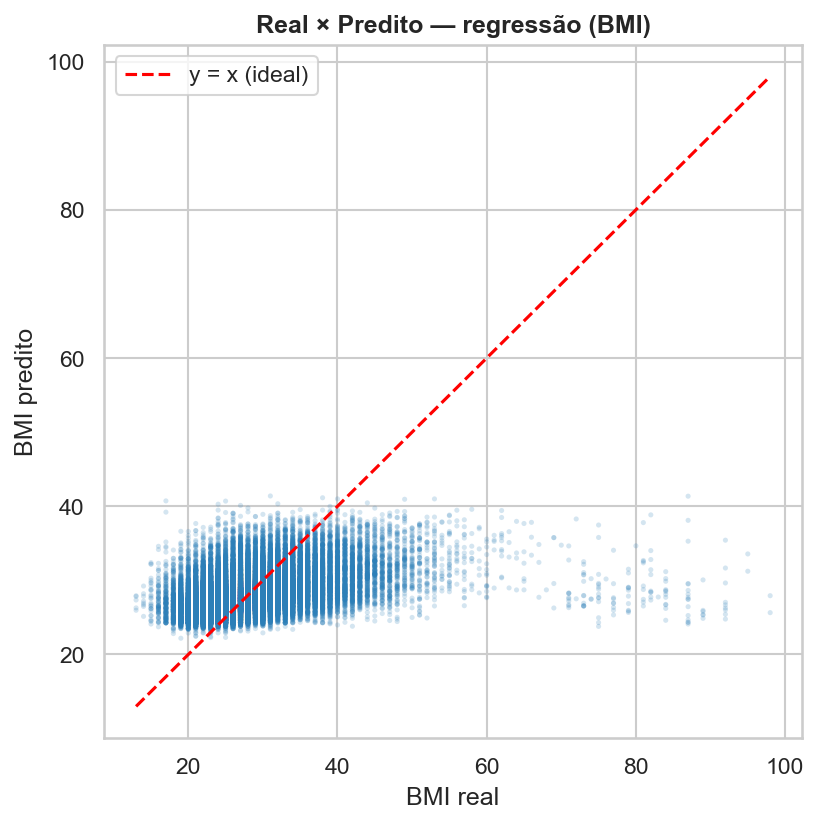

In [4]:
Image(str(config.FIGURES_DIR / "etapa5_real_vs_pred.png"))

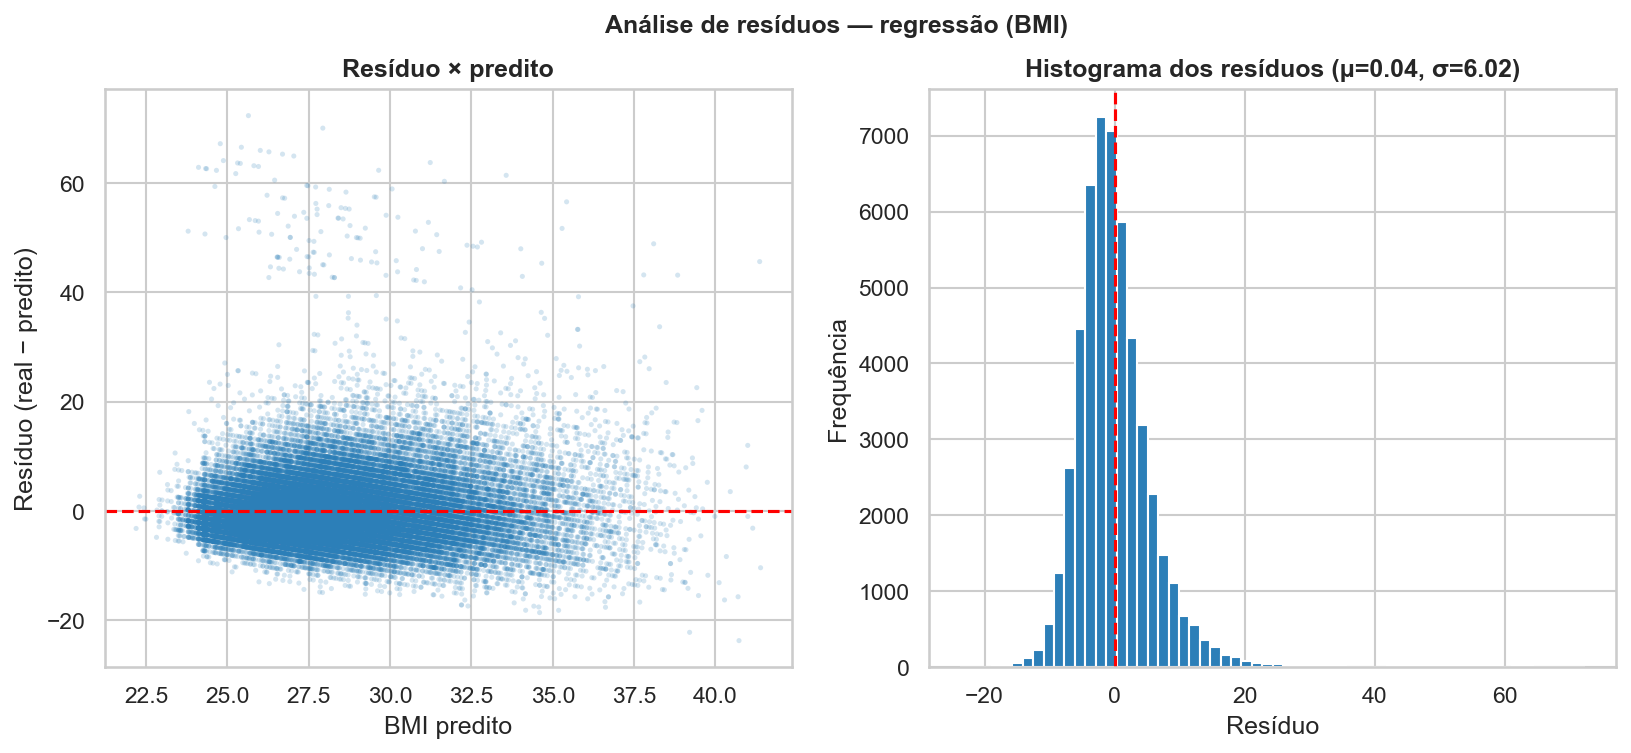

In [5]:
Image(str(config.FIGURES_DIR / "etapa5_residuos.png"))

## 4. Extra - comparação com modelos clássicos

`LinearRegression`, `Ridge`, `Lasso`, `RandomForest` e `XGBoost`, comparando MAE/RMSE/R²
e o custo computacional.

In [6]:
pd.read_csv(config.METRICS_DIR / "classical_comparison_regression.csv")

,modelo,mae,rmse,r2,tempo_treino_s,tempo_inferencia_s
0,LinearRegression,4.3190,6.1575,0.1367,0.02,0.0009
1,Ridge,4.3190,6.1575,0.1367,0.01,0.0008
2,Lasso,4.3189,6.1575,0.1367,0.05,0.0007
3,RandomForest,4.5511,6.4528,0.0519,5.11,0.4232
4,XGBoost,4.1968,6.0374,0.1700,0.50,0.0129
